<a href="https://colab.research.google.com/github/mtalhak003/AI-ML-Deep-Learning/blob/main/Transformer_Based_Daily_Gold_Price_Forecasting_Using_Historical_Time_Series_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
!pip install yfinance -q

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [60]:
data = yf.download(
    "GC=F",
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data = data[['Close']].dropna()

print(data.head())
print(data.shape)

[*********************100%***********************]  1 of 1 completed

Price             Close
Ticker             GC=F
Date                   
2010-01-04  1117.699951
2010-01-05  1118.099976
2010-01-06  1135.900024
2010-01-07  1133.099976
2010-01-08  1138.199951
(4023, 1)


### Attempting to download hourly gold price data

To make hourly predictions, we need hourly data. Let's try to download hourly data for `GC=F` from Yahoo Finance. Note that free APIs like `yfinance` often have limitations on the historical period available for hourly intervals.

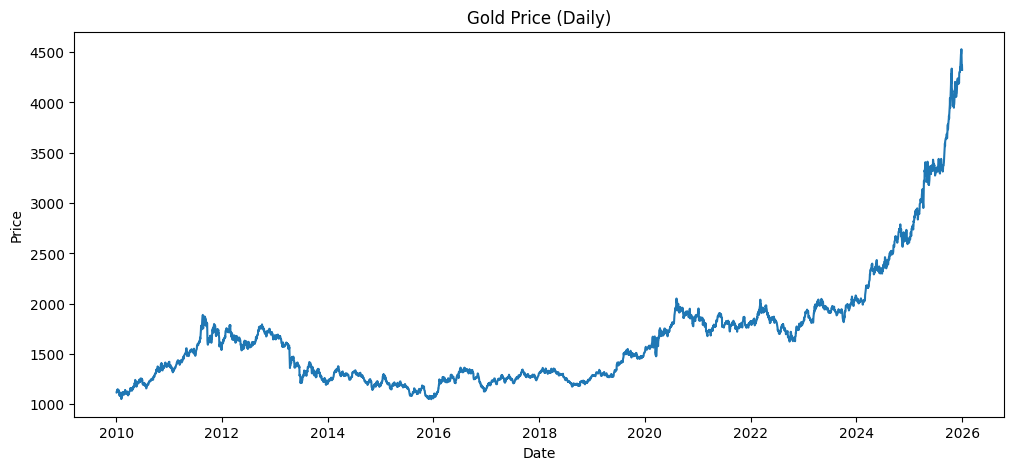

In [61]:

plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title("Gold Price (Daily)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [62]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Close']])

In [43]:
usd_to_pkr = 280

data["Gold_Price_PKR"] = data["Close"] * usd_to_pkr

print(data.head())

Price                            Close Gold_Price_PKR
Ticker                            GC=F               
Datetime                                             
2026-03-31 04:00:00+00:00  4592.899902   1.286012e+06
2026-03-31 05:00:00+00:00  4597.000000   1.287160e+06
2026-03-31 06:00:00+00:00  4586.399902   1.284192e+06
2026-03-31 07:00:00+00:00  4594.700195   1.286516e+06
2026-03-31 08:00:00+00:00  4599.000000   1.287720e+06


In [63]:
LOOKBACK = 60
FORECAST = 10

X, y = [], []

for i in range(len(scaled_data) - LOOKBACK - FORECAST):
    X.append(scaled_data[i:i+LOOKBACK])
    y.append(scaled_data[i+LOOKBACK:i+LOOKBACK+FORECAST])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3953, 60, 1)
y shape: (3953, 10, 1)


In [64]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(X_train.shape, X_val.shape, X_test.shape)

(2767, 60, 1) (592, 60, 1) (594, 60, 1)


In [65]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [73]:
batch_size = 64

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size
)

In [72]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))  # FIX

    def forward(self, x):
        pe = self.pe[:, :x.size(1)].to(x.device)     # FIX GPU/CPU match
        return x + pe

In [74]:
class GoldTransformer(nn.Module):
    def __init__(self, forecast=10):
        super().__init__()

        self.embedding = nn.Linear(1, 128)
        self.pos = PositionalEncoding(128)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=8,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        self.fc1 = nn.Linear(128, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, forecast)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x.unsqueeze(-1)

In [75]:
model = GoldTransformer(forecast=FORECAST).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [76]:
epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)
        loss = criterion(pred, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

Epoch 10 | Train Loss: 0.000283 | Val Loss: 0.000150
Epoch 20 | Train Loss: 0.000180 | Val Loss: 0.000148
Epoch 30 | Train Loss: 0.000153 | Val Loss: 0.000125
Epoch 40 | Train Loss: 0.000129 | Val Loss: 0.000191
Epoch 50 | Train Loss: 0.000127 | Val Loss: 0.000227
Epoch 60 | Train Loss: 0.000123 | Val Loss: 0.000239
Epoch 70 | Train Loss: 0.000110 | Val Loss: 0.000187
Epoch 80 | Train Loss: 0.000108 | Val Loss: 0.000203
Epoch 90 | Train Loss: 0.000102 | Val Loss: 0.000216
Epoch 100 | Train Loss: 0.000101 | Val Loss: 0.000205


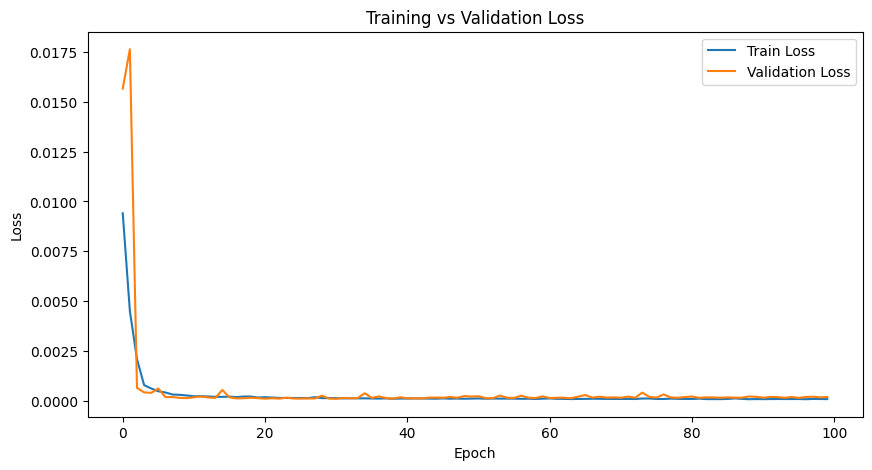

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [78]:
model.eval()

with torch.no_grad():
    preds = model(X_test.to(device))

preds = preds.cpu().numpy()
actual = y_test.numpy()

In [79]:
preds = scaler.inverse_transform(preds.reshape(-1, 1))
actual = scaler.inverse_transform(actual.reshape(-1, 1))

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, preds)
mse = mean_squared_error(actual, preds)
rmse = np.sqrt(mse)

mape = np.mean(np.abs((actual - preds) / actual)) * 100

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 782.93603515625
MSE : 1059253.75
RMSE: 1029.200539253648
MAPE: 24.446388


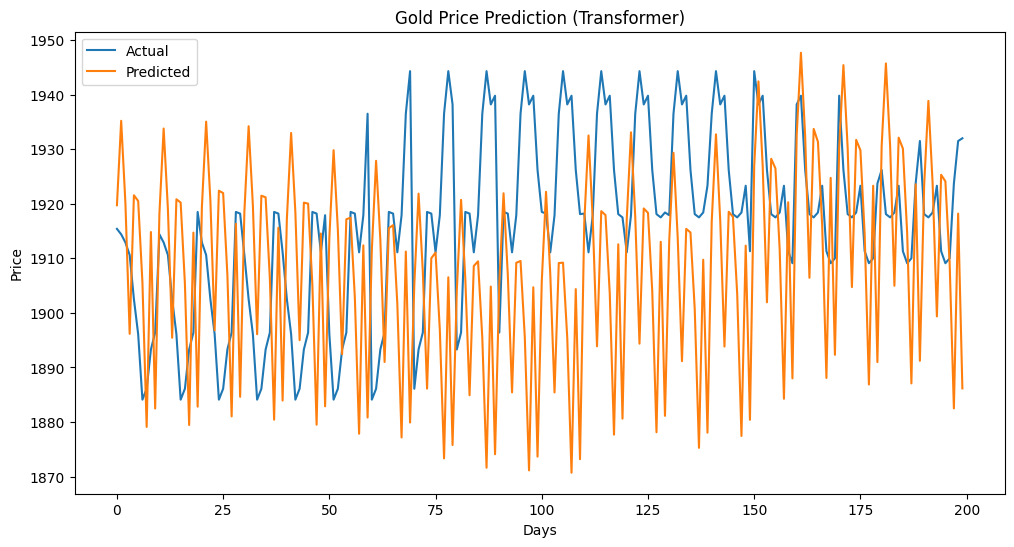

In [81]:
plt.figure(figsize=(12,6))

plt.plot(actual[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")

plt.title("Gold Price Prediction (Transformer)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

plt.show()

In [82]:
torch.save(model.state_dict(), "gold_transformer_fixed.pth")
print("Model saved successfully!")

Model saved successfully!


Next 6-Hour Predicted Gold Prices in PKR (First 10 predictions):
Hour 1: 1,256,069.88 PKR
Hour 2: 1,258,222.25 PKR
Hour 3: 1,257,833.00 PKR
Hour 4: 1,256,438.50 PKR
Hour 5: 1,257,679.50 PKR
Hour 6: 1,256,819.75 PKR
Hour 7: 1,256,895.00 PKR
Hour 8: 1,259,077.12 PKR
Hour 9: 1,258,523.38 PKR
Hour 10: 1,257,144.88 PKR


In [83]:
torch.save(model.state_dict(), "gold_transformer_pkr_model_6hr.pth")

In [85]:
LOOKBACK = 60
MAX_FORECAST = 6

X, y = [], []

for i in range(len(scaled_data) - LOOKBACK - MAX_FORECAST):

    X.append(scaled_data[i:i+LOOKBACK])

    future = scaled_data[i+LOOKBACK : i+LOOKBACK+MAX_FORECAST]

    # 1-step, 3-step, 6-step
    y.append([
        future[0, 0],
        future[2, 0],
        future[5, 0]
    ])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)   # MUST be (N, 3)

X shape: (3957, 60, 1)
y shape: (3957, 3)


In [86]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3165, 60, 1) (3165, 3)
(792, 60, 1) (792, 3)


In [87]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

In [88]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

In [89]:
class GoldTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(1, 128)
        self.pos = PositionalEncoding(128)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=8,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        self.fc1 = nn.Linear(128, 64)
        self.relu = nn.ReLU()

        # IMPORTANT: 3 outputs = 1, 3, 6 step
        self.fc2 = nn.Linear(64, 3)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos(x)
        x = self.transformer(x)

        x = x[:, -1, :]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [90]:
model = GoldTransformer().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [91]:
epochs = 100

for epoch in range(epochs):

    model.train()
    loss_sum = 0

    for i in range(0, len(X_train), 64):

        xb = X_train[i:i+64]
        yb = y_train[i:i+64]

        optimizer.zero_grad()

        pred = model(xb)

        loss = criterion(pred, yb)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} Loss: {loss_sum:.5f}")

Epoch 10 Loss: 0.44325
Epoch 20 Loss: 0.35520
Epoch 30 Loss: 0.33743
Epoch 40 Loss: 0.32423
Epoch 50 Loss: 0.31633
Epoch 60 Loss: 0.30912
Epoch 70 Loss: 0.30575
Epoch 80 Loss: 0.32443
Epoch 90 Loss: 0.32667
Epoch 100 Loss: 0.29352


In [92]:
model.eval()

with torch.no_grad():
    preds = model(X_test)

preds = preds.cpu().numpy()
actual = y_test.cpu().numpy()

print(preds.shape, actual.shape)  # MUST be (N, 3)

(792, 3) (792, 3)


In [93]:
# reshape for scaler
preds_2d = preds.reshape(-1, 1)
actual_2d = actual.reshape(-1, 1)

preds_inv = scaler.inverse_transform(preds_2d).reshape(-1, 3)
actual_inv = scaler.inverse_transform(actual_2d).reshape(-1, 3)

In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

labels = ["1-step", "3-step", "6-step"]

for i in range(3):

    mae = mean_absolute_error(actual_inv[:, i], preds_inv[:, i])
    rmse = np.sqrt(mean_squared_error(actual_inv[:, i], preds_inv[:, i]))
    mape = np.mean(np.abs((actual_inv[:, i] - preds_inv[:, i]) / actual_inv[:, i])) * 100

    print("\n===================")
    print(labels[i])
    print("===================")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape)


1-step
MAE : 1082.0333251953125
RMSE: 1284.8648761640268
MAPE: 38.84443

3-step
MAE : 1099.0501708984375
RMSE: 1302.1071384490601
MAPE: 39.399654

6-step
MAE : 1103.815673828125
RMSE: 1309.9644079134364
MAPE: 39.36949


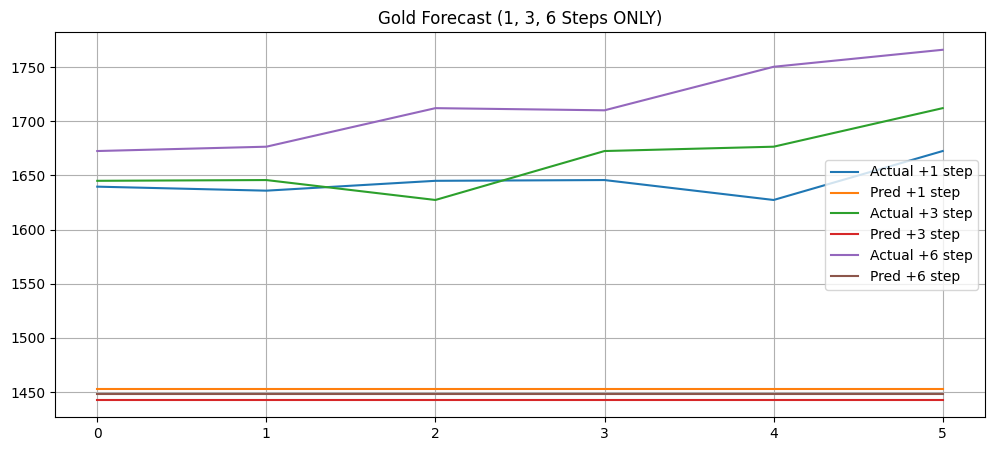

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# ONLY first 6 predictions (not 100)
plt.plot(actual_inv[:6, 0], label="Actual +1 step")
plt.plot(preds_inv[:6, 0], label="Pred +1 step")

plt.plot(actual_inv[:6, 1], label="Actual +3 step")
plt.plot(preds_inv[:6, 1], label="Pred +3 step")

plt.plot(actual_inv[:6, 2], label="Actual +6 step")
plt.plot(preds_inv[:6, 2], label="Pred +6 step")

plt.title("Gold Forecast (1, 3, 6 Steps ONLY)")
plt.legend()
plt.grid()
plt.show()

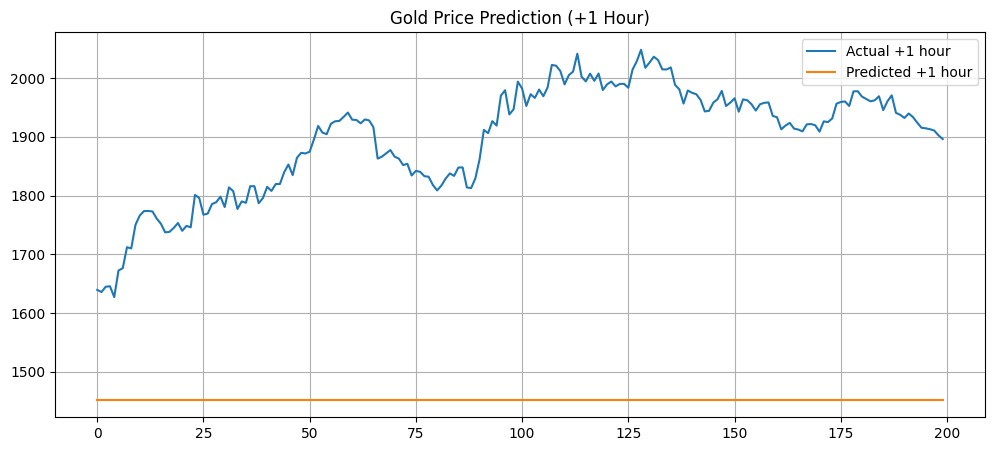

In [99]:
plt.figure(figsize=(12,5))

plt.plot(actual_inv[:200, 0], label="Actual +1 hour")
plt.plot(preds_inv[:200, 0], label="Predicted +1 hour")

plt.title("Gold Price Prediction (+1 Hour)")
plt.legend()
plt.grid()
plt.show()

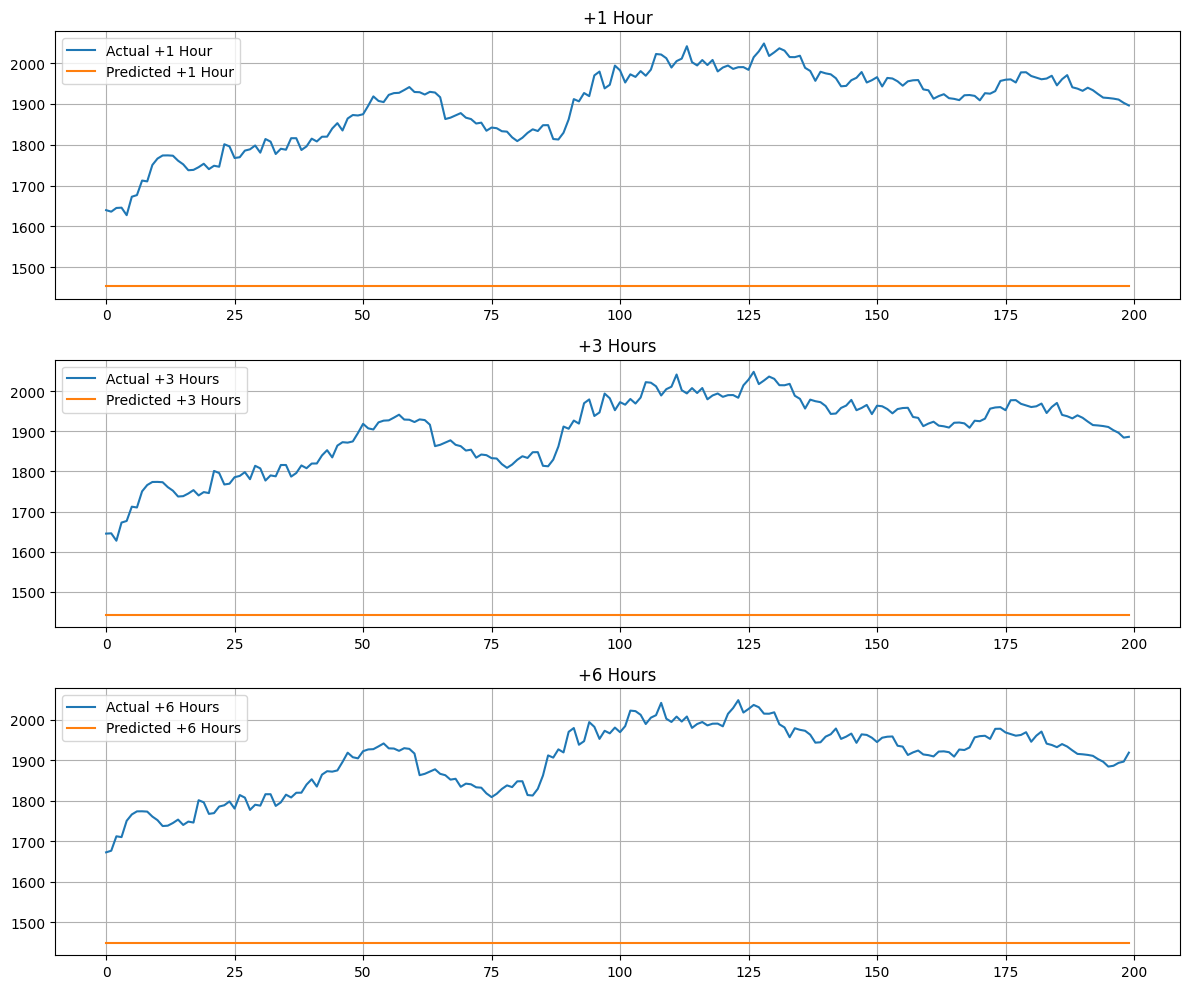

In [100]:
fig, axs = plt.subplots(3, 1, figsize=(12,10))

titles = ["+1 Hour", "+3 Hours", "+6 Hours"]

for i in range(3):
    axs[i].plot(actual_inv[:200, i], label=f"Actual {titles[i]}")
    axs[i].plot(preds_inv[:200, i], label=f"Predicted {titles[i]}")
    axs[i].set_title(titles[i])
    axs[i].legend()
    axs[i].grid()

plt.tight_layout()
plt.show()